In [9]:
import pandas as pd
import numpy as np
import PyMieScatt as ps
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [10]:

wavelength = 375  # nm
diameter = 300    # nm


# Valores de n (parte real) e k (parte imaginária)
n_values = np.linspace(1.0, 3.0, 1000)  # Reduzido para 100 pontos (mais rápido)
k_values = np.linspace(0.0001, 1.0, 1000)

# Grid de n e k
n_grid, k_grid = np.meshgrid(n_values, k_values, indexing='ij')

# Matriz para armazenar Qext
Qscat_results = np.zeros_like(n_grid, dtype=np.float64)
Qabs_results = np.zeros_like(n_grid, dtype=np.float64)

# Loop para calcular Qext (pode ser paralelizado para acelerar)
for i in range(len(n_values)):
    for j in range(len(k_values)):
        m = n_values[i] + 1j * k_values[j]
        Qscat_results[i, j] = ps.MieQ(m, wavelength, diameter, asDict=False)[1]  # Qscat
        Qabs_results[i, j] = ps.MieQ(m, wavelength, diameter, asDict=False)[2]  # Qabs

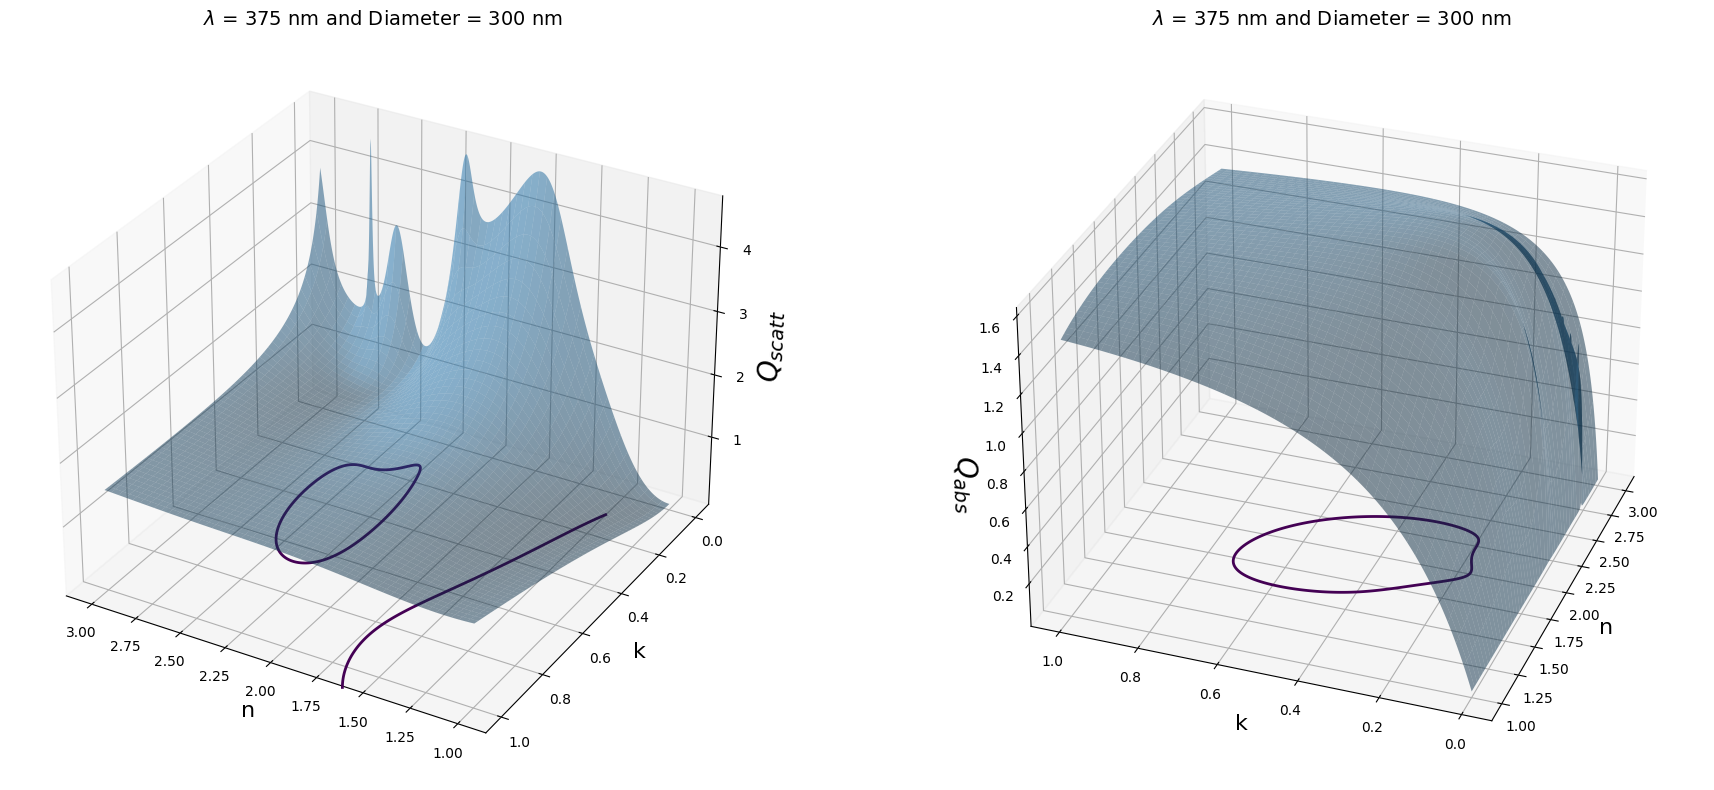

In [11]:
level_scatt = 1.315  # Valor único para Qscatt
level_abs = 1.544    # Valor único para Qabs  


# Criar figura com 2 subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), 
                              subplot_kw={'projection': '3d'})
# Loop para plotar Qscat e Qabs
for ax, data, title, ang_azim, level in zip([ax1, ax2], [Qscat_results, Qabs_results], 
                          ['$Q_{scatt}$', '$Q_{abs}$'],[120,200], [level_scatt, level_abs]):
    
    # Plot da superfície
    surf = ax.plot_surface(
        n_grid, 
        k_grid, 
        data, 
        edgecolor='none',
        alpha=0.5,
    )
    offset = np.min(data) - 0.1 * (np.max(data) - np.min(data))  # Ajuste o offset

    # Linhas de contorno pretas
    ax.contour(
        n_grid, k_grid, data, zdir='z', offset=offset,  # Adicionado offset
      linewidths=2.0, linestyles='solid', levels=[level]
    )
    
    # Configurações do gráfico
    ax.view_init(elev=30, azim=ang_azim)
    ax.set_xlabel('n', fontsize=16)
    ax.set_ylabel('k', fontsize=16)
    ax.set_zlabel(title, fontsize=20)
    ax.set_title(f'$\lambda$ = {wavelength} nm and Diameter = {diameter} nm', fontsize=14)

    # Barra de cores
    #fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6056/4264940697.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  cs1 = plt.contour(
/tmp/ipykernel_6056/4264940697.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  cs2 = plt.contour(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


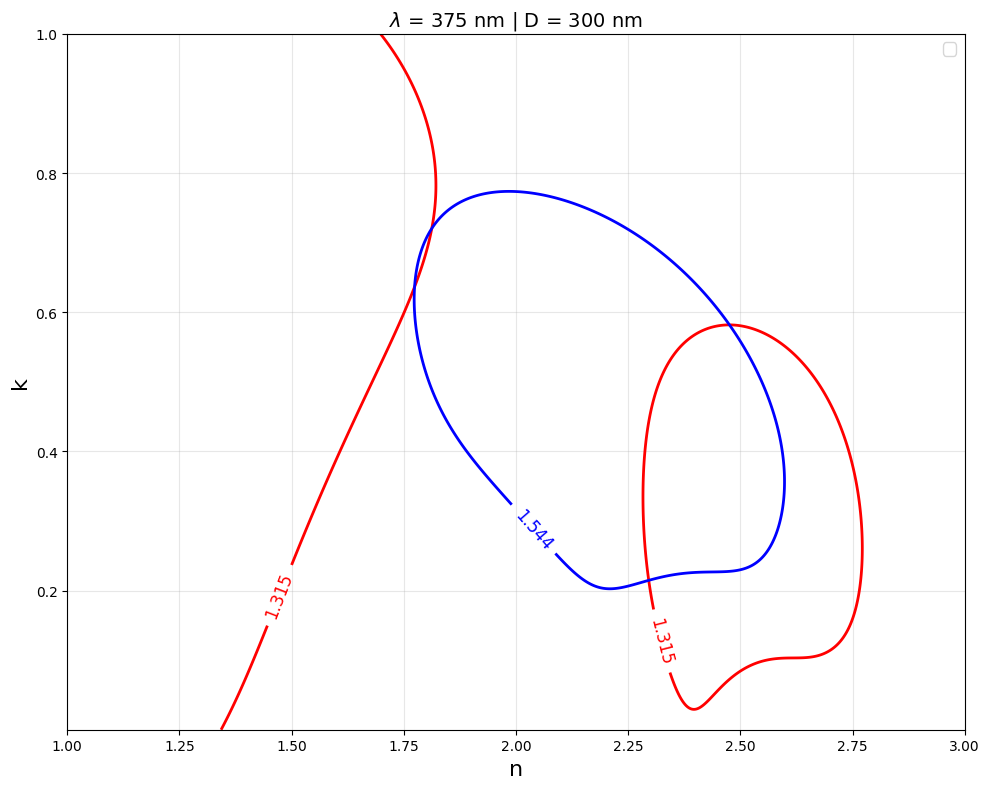

In [12]:
# Criar figura 2D separada para as curvas de nível
plt.figure(figsize=(10, 8))

# Plot da curva de nível para Qscatt
cs1 = plt.contour(
    n_grid, 
    k_grid, 
    Qscat_results, 
    levels=[level_scatt],
    colors='red',
    linewidths=2.0,
    linestyles='solid',
    label=f'$Q_{{scatt}} = {level_scatt:.3f}$'
)

# Plot da curva de nível para Qabs
cs2 = plt.contour(
    n_grid, 
    k_grid, 
    Qabs_results, 
    levels=[level_abs],
    colors='blue',
    linewidths=2.0,
    linestyles='solid',
    label=f'$Q_{{abs}} = {level_abs:.3f}$'
)

# Adicionar rótulos às curvas
plt.clabel(cs1, fontsize=12, fmt='%.3f', inline=True)
plt.clabel(cs2, fontsize=12, fmt='%.3f', inline=True)

# Configurações do gráfico
plt.xlabel('n', fontsize=16)
plt.ylabel('k', fontsize=16)
plt.title(f'$\lambda$ = {wavelength} nm | D = {diameter} nm', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

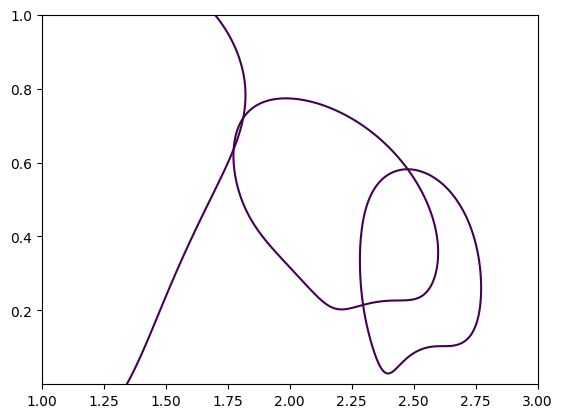

In [13]:
# Gerar curvas de nível
cs_scatt = plt.contour(n_grid, k_grid, Qscat_results, levels=[level_scatt])
cs_abs = plt.contour(n_grid, k_grid, Qabs_results, levels=[level_abs])

# Extrair pontos das curvas
scatt_points = cs_scatt.allsegs[0][0]  # Pontos da curva Qscatt
abs_points = cs_abs.allsegs[0][0]      # Pontos da curva Qabs

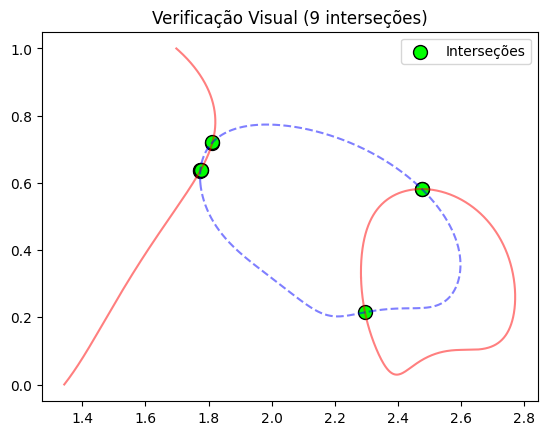

Interseções encontradas:
1: n = 1.774, k = 0.636
2: n = 1.774, k = 0.637
3: n = 1.775, k = 0.638
4: n = 1.775, k = 0.639
5: n = 1.812, k = 0.720
6: n = 1.812, k = 0.721
7: n = 2.296, k = 0.215
8: n = 2.475, k = 0.582
9: n = 2.477, k = 0.582


In [14]:
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

def encontrar_intersecoes_completas(n_grid, k_grid, Qscat, Qabs, level_scatt, level_abs, decimal_precision=3):
    # Configurar precisão
    threshold = 10**(-decimal_precision)
    
    # Extrair todas as curvas de nível (incluindo possíveis segmentos múltiplos)
    cs_scatt = plt.contour(n_grid, k_grid, Qscat, levels=[level_scatt])
    cs_abs = plt.contour(n_grid, k_grid, Qabs, levels=[level_abs])
    plt.close()  # Fechar figura não necessária
    
    # Coletar todos os segmentos de cada curva
    scatt_segments = [seg for seg in cs_scatt.allsegs[0] if len(seg) > 0]
    abs_segments = [seg for seg in cs_abs.allsegs[0] if len(seg) > 0]
    
    # Processar todos os segmentos
    intersections = []
    for scatt_seg in scatt_segments:
        scatt_seg = np.round(scatt_seg, decimal_precision)
        scatt_seg = np.unique(scatt_seg, axis=0)  # Remover duplicatas no segmento
        
        for abs_seg in abs_segments:
            abs_seg = np.round(abs_seg, decimal_precision)
            abs_seg = np.unique(abs_seg, axis=0)
            
            # Criar árvore para o segmento atual
            tree = KDTree(abs_seg)
            dists, _ = tree.query(scatt_seg)
            
            # Filtrar pontos próximos
            close_points = scatt_seg[dists < threshold]
            if len(close_points) > 0:
                # Agrupar pontos próximos para evitar repetições
                if len(close_points) > 1:
                    sub_tree = KDTree(close_points)
                    clusters = sub_tree.query_ball_point(close_points, r=threshold)
                    unique_indices = [cluster[0] for cluster in clusters]
                    close_points = close_points[np.unique(unique_indices)]
                
                intersections.extend(close_points)
    
    # Processar resultados finais
    if intersections:
        intersections = np.round(np.unique(np.vstack(intersections), axis=0), decimal_precision)
        
        # Verificação visual (opcional)
        plt.figure()
        for scatt_seg in scatt_segments:
            plt.plot(scatt_seg[:,0], scatt_seg[:,1], 'r-', alpha=0.5)
        for abs_seg in abs_segments:
            plt.plot(abs_seg[:,0], abs_seg[:,1], 'b--', alpha=0.5)
        plt.scatter(intersections[:,0], intersections[:,1], c='lime', s=100, 
                   edgecolors='k', label='Interseções')
        plt.legend()
        plt.title(f'Verificação Visual ({len(intersections)} interseções)')
        plt.show()
        
        return intersections
    else:
        return np.array([])

# Uso:
intersecoes = encontrar_intersecoes_completas(
    n_grid, k_grid,
    Qscat_results, Qabs_results,
    level_scatt=1.315,
    level_abs=1.544
)

print("Interseções encontradas:")
for i, (n, k) in enumerate(intersecoes):
    print(f"{i+1}: n = {n:.3f}, k = {k:.3f}")

import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

def encontrar_intersecoes_completas(n_grid, k_grid, Qscat, Qabs, level_scatt, level_abs, decimal_precision=3):
    # Configurar precisão
    threshold = 10**(-decimal_precision)
    
    # Extrair todas as curvas de nível (incluindo possíveis segmentos múltiplos)
    cs_scatt = plt.contour(n_grid, k_grid, Qscat, levels=[level_scatt])
    cs_abs = plt.contour(n_grid, k_grid, Qabs, levels=[level_abs])
    plt.close()  # Fechar figura não necessária
    
    # Coletar todos os segmentos de cada curva
    scatt_segments = [seg for seg in cs_scatt.allsegs[0] if len(seg) > 0]
    abs_segments = [seg for seg in cs_abs.allsegs[0] if len(seg) > 0]
    
    # Processar todos os segmentos
    intersections = []
    for scatt_seg in scatt_segments:
        scatt_seg = np.round(scatt_seg, decimal_precision)
        scatt_seg = np.unique(scatt_seg, axis=0)  # Remover duplicatas no segmento
        
        for abs_seg in abs_segments:
            abs_seg = np.round(abs_seg, decimal_precision)
            abs_seg = np.unique(abs_seg, axis=0)
            
            # Criar árvore para o segmento atual
            tree = KDTree(abs_seg)
            dists, _ = tree.query(scatt_seg)
            
            # Filtrar pontos próximos
            close_points = scatt_seg[dists < threshold]
            if len(close_points) > 0:
                # Agrupar pontos próximos para evitar repetições
                if len(close_points) > 1:
                    sub_tree = KDTree(close_points)
                    clusters = sub_tree.query_ball_point(close_points, r=threshold)
                    unique_indices = [cluster[0] for cluster in clusters]
                    close_points = close_points[np.unique(unique_indices)]
                
                intersections.extend(close_points)
    
    # Processar resultados finais
    if intersections:
        intersections = np.round(np.unique(np.vstack(intersections), axis=0), decimal_precision)
        
        # Verificação visual (opcional)
        plt.figure()
        for scatt_seg in scatt_segments:
            plt.plot(scatt_seg[:,0], scatt_seg[:,1], 'r-', alpha=0.5)
        for abs_seg in abs_segments:
            plt.plot(abs_seg[:,0], abs_seg[:,1], 'b--', alpha=0.5)
        plt.scatter(intersections[:,0], intersections[:,1], c='lime', s=100, 
                   edgecolors='k', label='Interseções')
        plt.legend()
        plt.title(f'Verificação Visual ({len(intersections)} interseções)')
        plt.show()
        
        return intersections
    else:
        return np.array([])

# Uso:
intersecoes = encontrar_intersecoes_completas(
    n_grid, k_grid,
    Qscat_results, Qabs_results,
    level_scatt=1.315,
    level_abs=1.544
)

print("Interseções encontradas:")
for i, (n, k) in enumerate(intersecoes):
    print(f"{i+1}: n = {n:.3f}, k = {k:.3f}")

Problema direto para vários indices de refração, ou seja, espalhamento/absorção com o parametro de tamanho. 

Estudar a relação do angstrom com o parametro de tamanho



bohren e huffman 2007(?), espalhamento mie referencia

In [ ]:
nohre